# Network Centrality Analysis: Custom Decay Centrality

This notebook implements, evaluates, and visualizes **Decay Centrality** across several standard network datasets, comparing it against classical centrality metrics like Degree, Closeness, Betweenness, PageRank, and Eigenvector centrality.

## Mathematical Formulation

Decay Centrality is a distance-based metric that measures how close a node is to all other reachable nodes in a network, weighted by a proximity decay parameter $\delta \in (0, 1)$.

For a graph $G = (V, E)$, the Decay Centrality of a node $x \in V$ is defined as:

$$C_{\text{decay}}(x) = \sum_{y \in V \setminus \{x\}} \delta^{d(x, y)}$$

Where:
- $d(x, y)$ is the shortest path distance between node $x$ and node $y$.
- $\delta$ is the decay parameter. If a node $y$ is unreachable from $x$, the distance $d(x, y) = \infty$, meaning $\delta^{\infty} = 0$.

## Notebook Workflow
1. **Data Loading**: Load standard social and biological networks (`soc-karate`, `dolphins`, `polbooks`, `reachability`).
2. **Shortest Path Computation**: Use Breadth-First Search (BFS) to compute single-source shortest paths.
3. **Decay Centrality Computation**: Compute scores using a custom implementation and an optimized NetworkX-based version.
4. **Evaluation & Saving**: Extract top-10 ranked nodes for each dataset and export results to CSV files.
5. **Correlation Analysis**: Compute Pearson, Spearman, and Kendall correlation coefficients between Decay Centrality and other traditional metrics.

In [1]:
import networkx as nx  # Import NetworkX library for network science and graph algorithms
import matplotlib.pyplot as plt  # Import Matplotlib's pyplot module for plot rendering and graphics
import pandas as pd  # Import Pandas library for data manipulation and analysis via DataFrames
import os  # Import Python's operating system interface to handle file path operations
from collections import deque  # Import double-ended queue from collections module for efficient BFS queuing
from scipy.stats import pearsonr, spearmanr, kendalltau  # Import scientific statistical correlation methods
import numpy as np  # Import NumPy library for optimized array computations and mathematical operations
import textwrap  # Import textwrap to auto-wrap excessively long node labels


def load_evaluation_datasets():
    """Loads evaluation datasets including GML and edge-list graph formats."""
    datasets = {}  # Initialize an empty dictionary to hold our network datasets

    # Load the classic Zachary's Karate Club social network from networkx's built-in graph generators
    datasets['soc-karate'] = nx.karate_club_graph()

    # Load the Dolphins social network GML file using networkx's GML parser
    datasets['dolphins'] = nx.read_gml('dolphins.gml')

    # Load the US political books network GML file using networkx's GML parser
    datasets['polbooks'] = nx.read_gml('polbooks.gml')

    # Load a directed transportation reachability graph from an edge list text file
    datasets['reachability'] = nx.read_edgelist('reachability.txt', create_using=nx.DiGraph(), data=False)

    # Print out confirmation summarizing the successfully imported graph files
    print(f"Successfully loaded {len(datasets)} datasets: {list(datasets.keys())}")
    return datasets  # Return the collection of loaded network graphs

graphs = load_evaluation_datasets()  # Execute the graph loading function and save the returned dictionary

Successfully loaded 4 datasets: ['soc-karate', 'dolphins', 'polbooks', 'reachability']


---

### 1. Shortest Path Function

The following function uses Breadth-First Search (BFS) to find the shortest path length from a given source node to all other reachable nodes.

In [2]:
def bfs_shortest_path_lengths(G, source):
    """Finds shortest path lengths from a source node to all reachable nodes using BFS."""
    distances = {source: 0}  # Initialize distances dictionary, mapping the source node to distance 0
    queue = deque([source])  # Initialize a double-ended queue with the source node to manage the BFS frontier

    while queue:  # Run the loop until there are no more nodes remaining in our exploration queue
        current = queue.popleft()  # Retrieve and remove the next node to expand from the left of the queue
        current_dist = distances[current]  # Store the shortest distance of the current node from the source

        for neighbor in G.neighbors(current):  # Loop through each immediate neighbor of the current active node
            if neighbor not in distances:  # Check if this neighbor has not been reached or visited yet
                distances[neighbor] = current_dist + 1  # Save neighbor's distance as parent's distance plus 1
                queue.append(neighbor)  # Queue this unvisited neighbor to explore its outer connections later

    return distances  # Return the final dictionary mapping reachable nodes to their shortest path step distances

### 2. Decay Centrality Implementation

This cell defines our core mathematical formula for Decay Centrality, allowing calculation for a single node or for all nodes across the entire network.

In [3]:
def decay_centrality(G, u=None, delta=0.5):
    """Calculates custom Decay Centrality for a specific node or the entire graph."""
    def _single_node_decay(node):  # Helper function to compute centrality score for a single individual node
        distances = bfs_shortest_path_lengths(G, node)  # Get the shortest path distances using our custom BFS

        total_decay = 0  # Initialize a tracking variable to accumulate decayed proximity values

        for n, d in distances.items():  # Loop through all reachable nodes and their computed distances
            if n != node:  # Exclude the node itself from accumulating centrality points
                total_decay += delta ** d  # Add delta raised to the power of the shortest path length to sum

        return total_decay  # Return the computed cumulative decay centrality score for this specific node

    if u is not None:  # If a specific target node u was requested, only calculate and return its score
        return _single_node_decay(u)  # Compute and return the score for node u

    # Otherwise, calculate decay scores for all nodes in the graph G and return as a mapping dict
    return {n: _single_node_decay(n) for n in G.nodes()}

print("decay_centrality() defined successfully.")  # Output a confirmation message verifying function creation

decay_centrality() defined successfully.


### 3. Optimized Decay Centrality

An alternative, faster implementation of Decay Centrality leveraging NetworkX's built-in, highly optimized single-source shortest path calculation.

In [4]:
def decay_centrality_nx_optimized(G, delta=0.5):
    """Calculates optimized Decay Centrality utilizing NetworkX's native shortest path calculations."""
    centralities = {}  # Initialize an empty dictionary to store computed centrality scores for all nodes
    for node in G.nodes():  # Loop through every node present in the graph collection
        paths = nx.single_source_shortest_path_length(G, node)  # Use native NetworkX BFS solver for speed

        total_decay = 0  # Reset the accumulation sum to zero for the current node

        for n, dist in paths.items():  # Loop through each target node and its shortest path distance
            if n != node:  # Ensure a node does not measure a path distance decay to itself
                total_decay += delta ** dist  # Increment total decay sum by proximity parameter raised to distance

        centralities[node] = total_decay  # Map the accumulated centrality score to its corresponding node ID

    return centralities  # Return the finished dictionary with centrality scores mapped to each graph node

### 4. Running Evaluations and Exporting Tables

In this section, we run both centrality implementations on all four datasets, rank the top 10 nodes for each, and save the results as CSV files.

In [5]:
delta_value = 0.5  # Define the decay factor parameter delta to weight node proximity

for name, G in graphs.items():  # Loop through each network graph in our loaded dataset directory
    # Print out summary statistics describing the current graph being analyzed
    print(f"Evaluating {name} (Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()})...")

    current_graph_results = []  # Initialize an empty list to gather evaluation data for this specific graph

    custom_decay = decay_centrality(G, delta=delta_value)  # Compute scores using our basic BFS implementation
    nx_optimized_decay = decay_centrality_nx_optimized(G, delta=delta_value)  # Compute scores with optimized version

    # Sort the nodes by custom decay centrality in descending order to identify top central actors
    sorted_nodes = sorted(custom_decay.items(), key=lambda item: item[1], reverse=True)

    # Extract information for the top 10 ranked nodes for visualization and tabular analysis
    for rank, (node, d_cent) in enumerate(sorted_nodes[:10], start=1):
        current_graph_results.append({  # Append node metadata and results dictionary to our results list
            'Dataset': name,  # Store the current network dataset's identifying name
            'Rank': rank,  # Store the ordinal rank from 1 to 10
            'Node ID': node,  # Store the unique identifier of the node in the network
            'Custom Decay Centrality': round(d_cent, 4),  # Round custom centrality calculation to 4 decimals
            'NX-Optimized Decay Centrality': round(nx_optimized_decay[node], 4)  # Round optimized calculation
        })

    results_df = pd.DataFrame(current_graph_results)  # Convert the evaluation list into a clean Pandas DataFrame

    filename = f"{name}_results.csv"  # Create a standardized output filename based on the dataset name

    results_df.to_csv(filename, index=False)  # Export the compiled ranking DataFrame into a CSV format

    print(f"Saved {name} results to '{filename}'.")  # Print a confirmation message indicating successful saving
    display(results_df)  # Render the formatted tabular ranking directly to the notebook screen

# Inform the user that the computation loop has finished generating all files
print("\nAll evaluations complete. Individual CSV files have been generated.")

Evaluating soc-karate (Nodes: 34, Edges: 78)...
Saved soc-karate results to 'soc-karate_results.csv'.


,Dataset,Rank,Node ID,Custom Decay Centrality,NX-Optimized Decay Centrality
0,soc-karate,1,0,11.2500,11.2500
1,soc-karate,2,33,11.1875,11.1875
2,soc-karate,3,2,10.3750,10.3750
3,soc-karate,4,32,10.0625,10.0625
4,soc-karate,5,31,9.6250,9.6250
5,soc-karate,6,1,9.1250,9.1250
6,soc-karate,7,8,9.1250,9.1250
7,soc-karate,8,13,9.1250,9.1250
8,soc-karate,9,19,8.6250,8.6250
9,soc-karate,10,3,8.3750,8.3750


Evaluating dolphins (Nodes: 62, Edges: 159)...
Saved dolphins results to 'dolphins_results.csv'.


,Dataset,Rank,Node ID,Custom Decay Centrality,NX-Optimized Decay Centrality
0,dolphins,1,SN4,13.8281,13.8281
1,dolphins,2,Grin,13.5469,13.5469
2,dolphins,3,SN100,13.4688,13.4688
3,dolphins,4,SN9,13.3438,13.3438
4,dolphins,5,Kringel,13.2031,13.2031
5,dolphins,6,Scabs,12.6719,12.6719
6,dolphins,7,Topless,12.5391,12.5391
7,dolphins,8,TR99,12.1641,12.1641
8,dolphins,9,Beescratch,11.9062,11.9062
9,dolphins,10,Patchback,11.6484,11.6484


Evaluating polbooks (Nodes: 105, Edges: 441)...
Saved polbooks results to 'polbooks_results.csv'.


,Dataset,Rank,Node ID,Custom Decay Centrality,NX-Optimized Decay Centrality
0,polbooks,1,The Price of Loyalty,24.5312,24.5312
1,polbooks,2,Off with Their Heads,23.8125,23.8125
2,polbooks,3,A National Party No More,23.6250,23.6250
3,polbooks,4,American Dynasty,23.3438,23.3438
4,polbooks,5,Bush Country,23.1875,23.1875
5,polbooks,6,Losing Bin Laden,23.0938,23.0938
6,polbooks,7,The Great Unraveling,22.7500,22.7500
7,polbooks,8,Bushwhacked,22.3125,22.3125
8,polbooks,9,Rise of the Vulcans,22.1875,22.1875
9,polbooks,10,Plan of Attack,21.8125,21.8125


Evaluating reachability (Nodes: 456, Edges: 71959)...
Saved reachability results to 'reachability_results.csv'.


,Dataset,Rank,Node ID,Custom Decay Centrality,NX-Optimized Decay Centrality
0,reachability,1,246,224.50,224.50
1,reachability,2,230,221.75,221.75
2,reachability,3,74,221.25,221.25
3,reachability,4,368,221.25,221.25
4,reachability,5,100,221.00,221.00
5,reachability,6,294,220.75,220.75
6,reachability,7,94,220.50,220.50
7,reachability,8,434,220.50,220.50
8,reachability,9,324,219.75,219.75
9,reachability,10,416,216.00,216.00



All evaluations complete. Individual CSV files have been generated.


In [6]:
def visualize_decay_graph(
    G,
    name,
    centralities,
    delta=0.5,
    top_n_labels=10,
    figsize=(19, 11),
    save=True
):


    # Create lookup map using stripped string keys to fix matching issues
    node_lookup = {
        str(node).strip(): node
        for node in G.nodes()
    }

    fixed_centralities = {}  # Initialize dictionary to hold correctly matched node-to-score mappings

    for node, value in centralities.items():  # Loop through items in the user-supplied centralities dictionary

        matched_node = node_lookup.get(str(node).strip())  # Try to find a matching node key in current graph

        if matched_node is not None:  # If a matching node key indeed exists in the network structure

            try:
                fixed_centralities[matched_node] = float(value)  # Cast centrality score to float and save
            except (TypeError, ValueError):  # Catch casting exceptions if data contains invalid numeric structures
                continue  # Ignore problematic records and proceed with loop

    centralities = fixed_centralities  # Replace old dictionary with the cleaned, matched dictionary

    if not centralities:  # If no node keys matched successfully, raise an error to prevent blank plot rendering

        raise ValueError(
            "No centrality values matched the graph nodes. "
            "Check your centrality dictionary."
        )

    # Convert matched centrality scores into a NumPy array for math processing
    values = np.array(
        list(centralities.values()),
        dtype=float
    )

    min_cent = values.min()  # Determine minimum centrality score for normalization mapping boundaries
    max_cent = values.max()  # Determine maximum centrality score for normalization mapping boundaries

    visual_graph = nx.Graph()  # Initialize a blank temporary network graph structure

    visual_graph.add_nodes_from(G.nodes())  # Copy original graph node identifiers into the visual layout graph

    for u, v, data in G.edges(data=True):  # Loop through existing connections and extract edge attribute maps

        if u == v:  # Filter out self-loops to keep the visualization clean
            continue

        weight = data.get("weight", 1)  # Fetch edge weight value, defaulting to 1 if not defined

        try:
            similarity = -float(weight)  # Treat heavy distances as low similarity by negating weight value
        except (TypeError, ValueError):  # Catch casting errors
            similarity = 1  # Fall back to constant similarity of 1


        if visual_graph.has_edge(u, v):  # If this visual link already exists, check if weight needs update

            if similarity > visual_graph[u][v]["similarity"]:  # Check if new path has higher proximity
                visual_graph[u][v]["similarity"] = similarity  # Update to store the higher similarity value

        else:  # If this link does not exist, add it to the visual graph

            visual_graph.add_edge(
                u,
                v,
                similarity=similarity
            )


    if nx.is_connected(visual_graph):  # If the visual network is fully connected

        # Create a maximum spanning tree backbone based on similarity weights to ensure structural connectivity
        backbone = nx.maximum_spanning_tree(
            visual_graph,
            weight="similarity"
        )

    else:  # If network is disconnected, build a spanning tree backbone component-by-component

        backbone = nx.Graph()  # Initialize a blank graph to store disconnected tree segments

        for component in nx.connected_components(visual_graph):  # Loop through isolated components

            component_graph = visual_graph.subgraph(component)  # Isolate subgraph for current component

            tree = nx.maximum_spanning_tree(  # Generate a spanning tree for the current component
                component_graph,
                weight="similarity"
            )

            backbone.add_edges_from(tree.edges(data=True))  # Add component tree edges to visual backbone


    # Set maximum limit of extra visual lines to keep plots readable
    extra_edges = min(
        100,
        max(20, G.number_of_nodes() * 2)
    )

    # Sort visual edges in descending order based on similarity scores
    candidate_edges = sorted(
        visual_graph.edges(data=True),
        key=lambda x: x[2].get("similarity", 0),
        reverse=True
    )

    added = 0  # Initialize variable to track number of added extra edges

    for u, v, data in candidate_edges:  # Loop through similarity candidate edges

        if added >= extra_edges:  # Break the loop if we have hit the visual line limit
            break

        if not backbone.has_edge(u, v):  # If visual link is not in spanning tree backbone

            backbone.add_edge(u, v, **data)  # Add link with attributes into layout network

            added += 1  # Increment visual link tracking count


    n = max(G.number_of_nodes(), 1)  # Ensure node count variable is at least 1

    # Generate coordinates for nodes using a spring layout
    pos = nx.spring_layout(
        backbone,
        seed=42,
        k=2.0 / np.sqrt(n),
        iterations=1000,
        weight=None,
        scale=3.5
    )

    # Initialize matplotlib drawing canvas and axes
    fig, ax = plt.subplots(
        figsize=figsize,
        dpi=240
    )

    fig.patch.set_facecolor("white")  # Color the outer figure background pure white
    ax.set_facecolor("white")  # Color the plotting axes surface pure white


    # Render visual layout edges with a soft color and low opacity
    nx.draw_networkx_edges(
        backbone,
        pos,
        ax=ax,
        edge_color="#B8C7D9",
        width=0.65,
        alpha=0.38
    )


    # Gather list of nodes for which we have active centrality metrics
    centrality_nodes = [
        node for node in G.nodes()
        if node in centralities
    ]

    # Gather list of nodes that lack associated centrality mapping info
    other_nodes = [
        node for node in G.nodes()
        if node not in centralities
    ]


    def node_size(value):  # Define function to normalize and scale node markers based on scores

        if max_cent == min_cent:  # Guard against division-by-zero error on constant networks
            normalized = 1  # Fall back to constant scale of 1
        else:
            normalized = (  # Map the centrality value linearly between 0 and 1
                (value - min_cent) /
                (max_cent - min_cent)
            )

        return 80 + 650 * normalized**1.2  # Return scaled size with a minimum baseline of 80


    if centrality_nodes:  # If we have nodes with active centrality metrics

        # Compute individual layout sizes for all key nodes
        sizes = [
            node_size(centralities[node])
            for node in centrality_nodes
        ]

        # Retrieve raw centrality scores to map colors to colormap scale
        colors = [
            centralities[node]
            for node in centrality_nodes
        ]

        # Render key node markers with custom size, outline, and blue gradient
        nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax,
            nodelist=centrality_nodes,
            node_size=sizes,
            node_color=colors,
            cmap=plt.cm.Blues,
            vmin=min_cent,
            vmax=max_cent,
            edgecolors="white",
            linewidths=0.7,
            alpha=0.98
        )


    if other_nodes:  # If there are any non-ranked nodes remaining

        # Render remaining nodes with constant small size and a neutral color
        nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax,
            nodelist=other_nodes,
            node_size=32,
            node_color="#DCEAF5",
            edgecolors="white",
            linewidths=0.4,
            alpha=0.65
        )

    # Sort nodes in descending order and slice the top-N elements for annotation
    top_nodes = sorted(
        centralities.items(),
        key=lambda x: x[1],
        reverse=True
    )[:top_n_labels]

    for node, value in top_nodes:  # Loop through coordinates of highest ranked elements

        if node not in pos:  # Skip if node coordinates are missing from layout
            continue

        x, y = pos[node]  # Retrieve layout coordinate points

        label = str(node)  # Convert node object to string label

        if len(label) > 22:  # Wrap string to new line if text string is long

            label = textwrap.fill(
                label,
                width=17
            )

        # Create callout boxes on nodes displaying name and value
        ax.annotate(
            f"{label}\n{value:.2f}",
            (x, y),
            xytext=(0, 11),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color="#08306B",
            bbox=dict(
                boxstyle="round,pad=0.28",
                facecolor="white",
                edgecolor="#A8C5DF",
                linewidth=0.7,
                alpha=0.96
            ),
            zorder=10
        )

    # Create scalar mapping reference for colormap
    sm = plt.cm.ScalarMappable(
        cmap=plt.cm.Blues,
        norm=plt.Normalize(
            vmin=min_cent,
            vmax=max_cent
        )
    )

    sm.set_array([])  # Feed empty array to prevent unnecessary data plotting on colorbar axis

    # Add a matching colorbar to the plot
    cbar = fig.colorbar(
        sm,
        ax=ax,
        fraction=0.022,
        pad=0.015,
        shrink=0.80
    )

    # Set title label describing the colorbar
    cbar.set_label(
        "Decay Centrality (supplied CSV)",
        fontsize=11
    )

    cbar.ax.tick_params(labelsize=9)  # Set colorbar tick font sizes

    # Establish readable titles mapping the short names to complete network titles
    title_map = {
        "dolphins": "Dolphins Social Network",
        "polbooks": "US Political Books Network",
        "soc-karate": "Zachary's Karate Club Network",
        "reachability": "Transportation Reachability Network"
    }

    title = title_map.get(
        name,
        f"{name} Network"
    )

    # Render main title header at the top of plotting window
    ax.set_title(
        f"{title} — Decay Centrality",
        fontsize=22,
        fontweight="bold",
        color="#0B2545",
        pad=18
    )

    # Render subtitle description below main title
    ax.text(
        0.5,
        0.985,
        "Node size and color highlight the supplied decay-centrality values",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=10,
        color="#526579"
    )


    # Render footnote details describing graph dimensions and missing-node styling
    ax.text(
        0.01,
        0.015,
        (
            f"{G.number_of_nodes()} nodes • "
            f"{G.number_of_edges()} edges • "
            f"Remaining nodes shown small when centrality "
            f"is unavailable in the CSV"
        ),
        transform=ax.transAxes,
        fontsize=9,
        color="#718096"
    )

    ax.set_axis_off()  # Hide layout axes boundaries to keep the plot clean

    plt.tight_layout()  # Automatically adjust layout space to prevent text overlap


    if save:  # If image export setting is enabled

        filename = (
            f"{name}_decay_centrality_presentation.png"
        )

        # Save current plot to local file system directory in high resolution
        plt.savefig(
            filename,
            dpi=320,
            bbox_inches="tight",
            facecolor="white"
        )

        print(f"Graph saved as: {filename}")  # Print file creation confirmation

    plt.show()  # Display plot on notebook screen

    return fig, ax  # Return the figure and axes objects for future modification


Generating graph: soc-karate
Nodes: 34 | Edges: 78
Loaded 10 ranked Decay Centrality values.
Graph saved as: soc-karate_decay_centrality_presentation.png


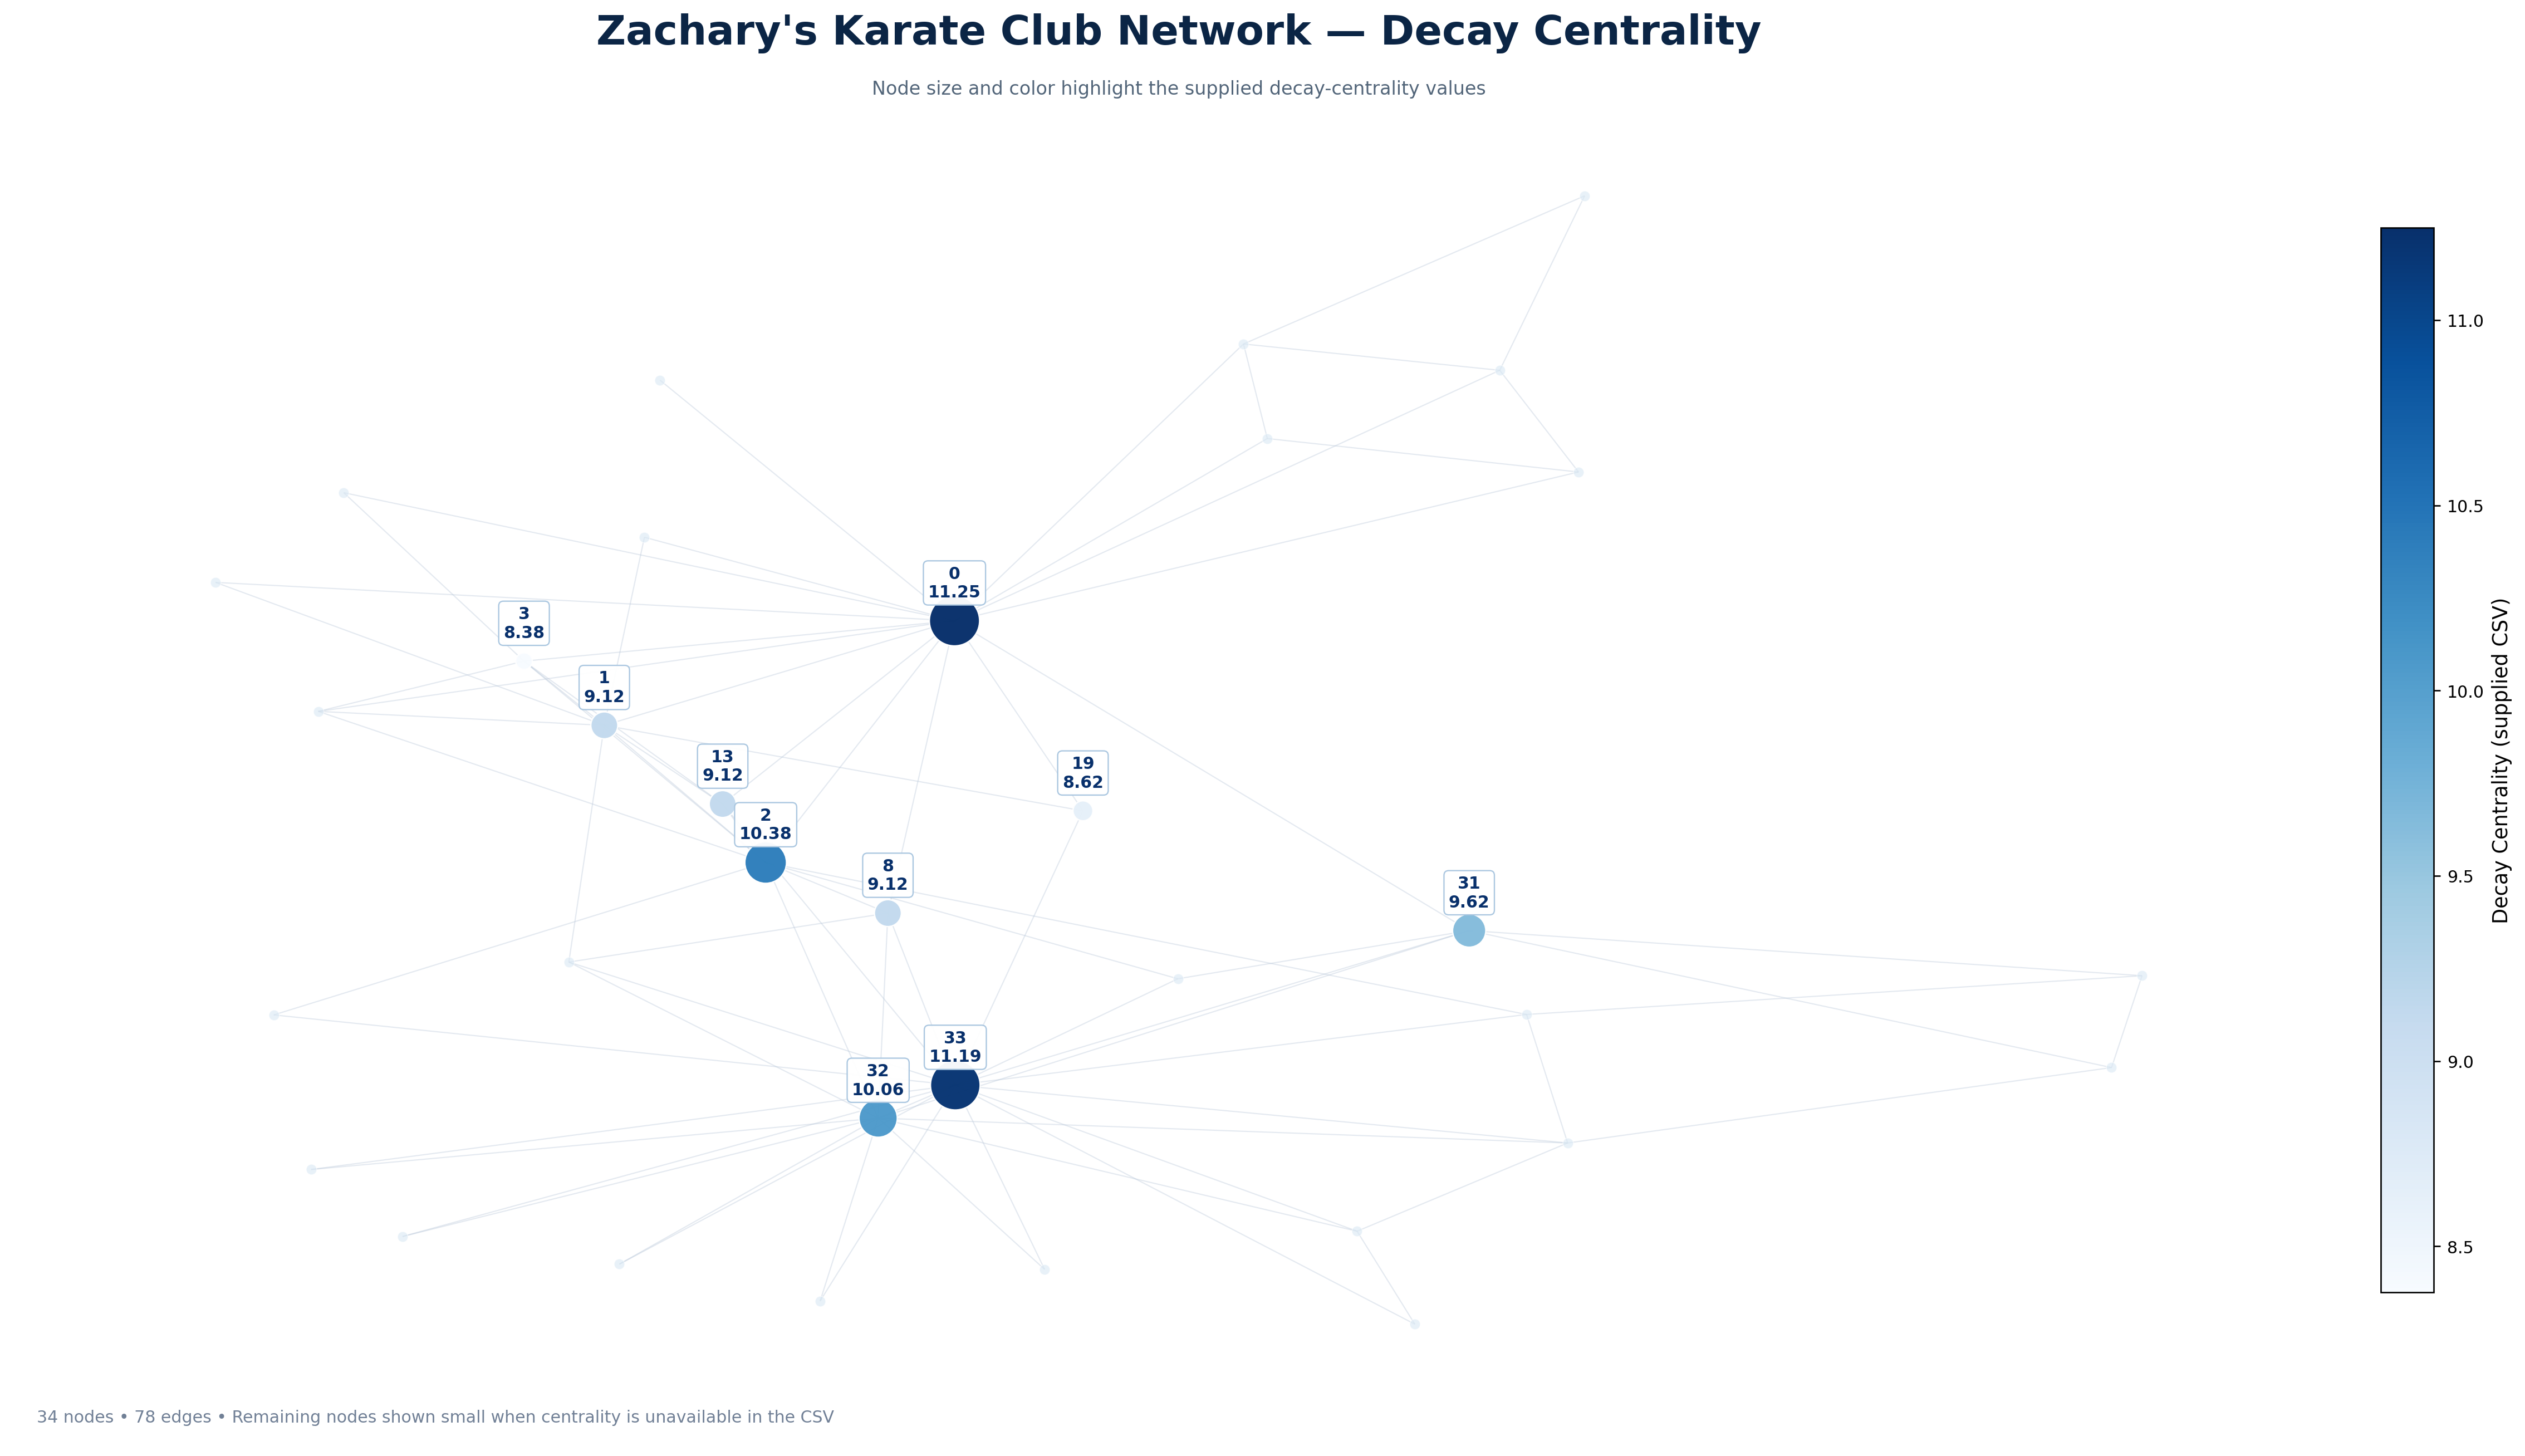

Completed visualization for soc-karate

Generating graph: dolphins
Nodes: 62 | Edges: 159
Loaded 10 ranked Decay Centrality values.
Graph saved as: dolphins_decay_centrality_presentation.png


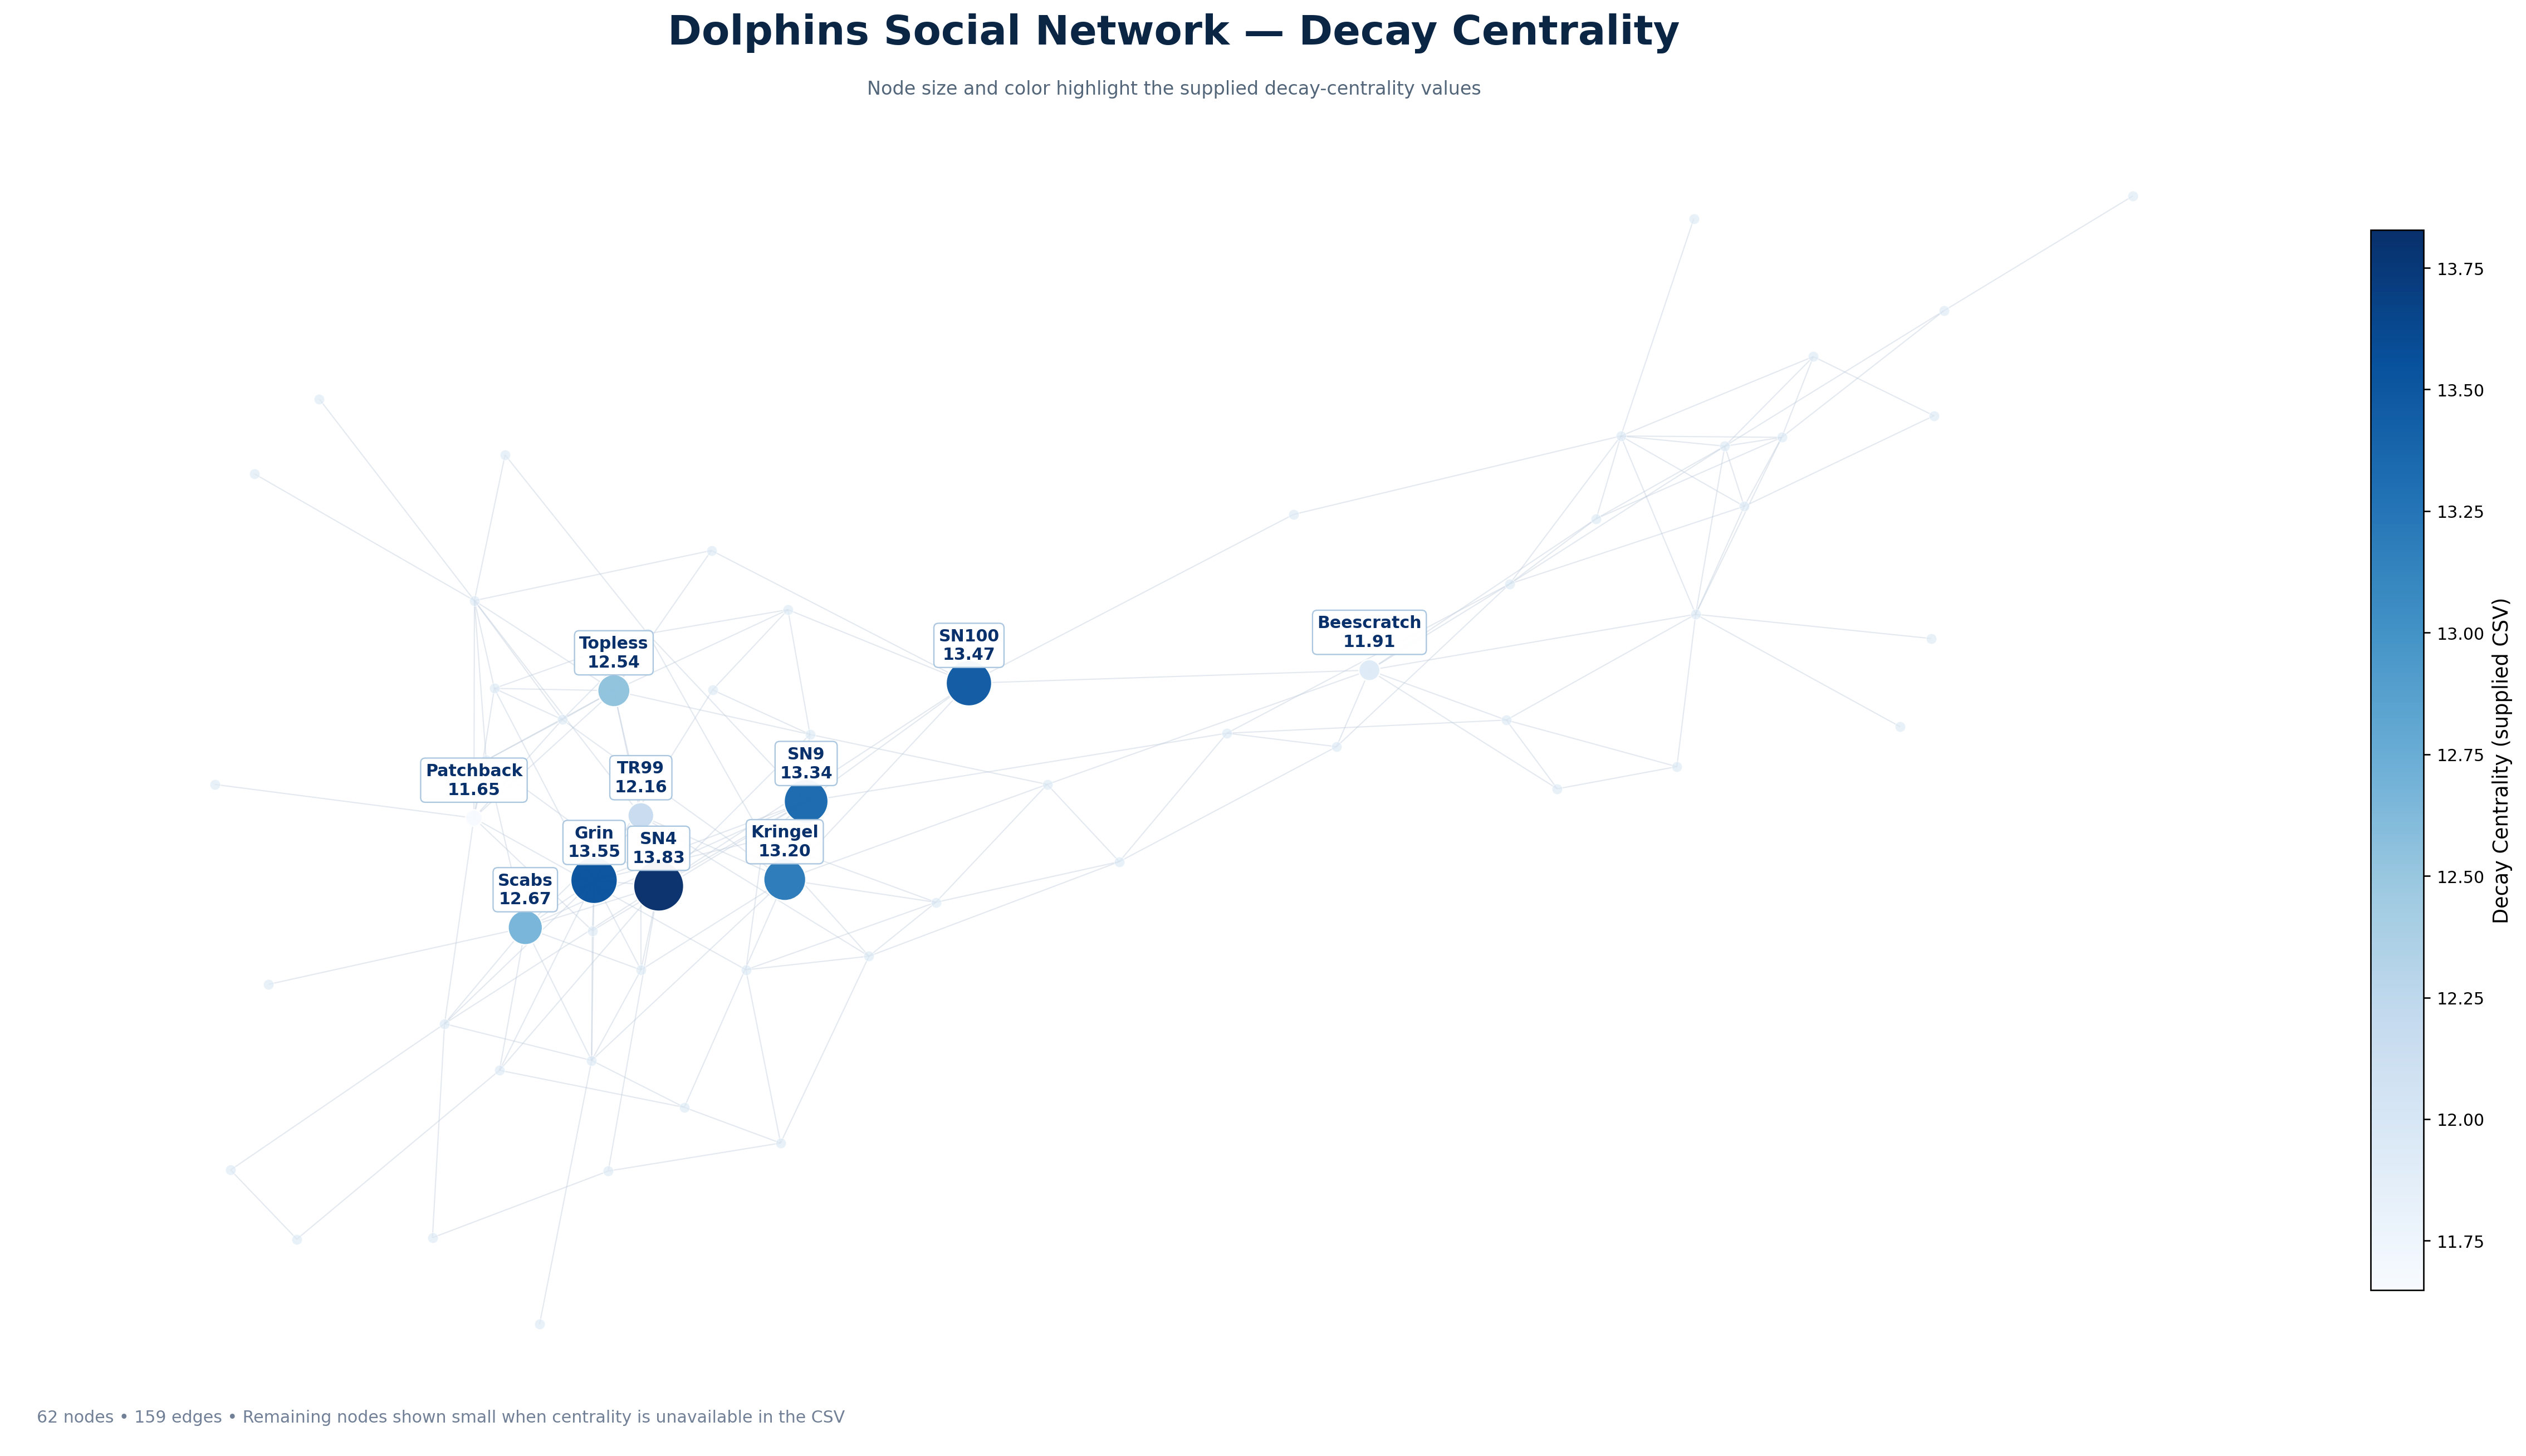

Completed visualization for dolphins

Generating graph: polbooks
Nodes: 105 | Edges: 441
Loaded 10 ranked Decay Centrality values.
Graph saved as: polbooks_decay_centrality_presentation.png


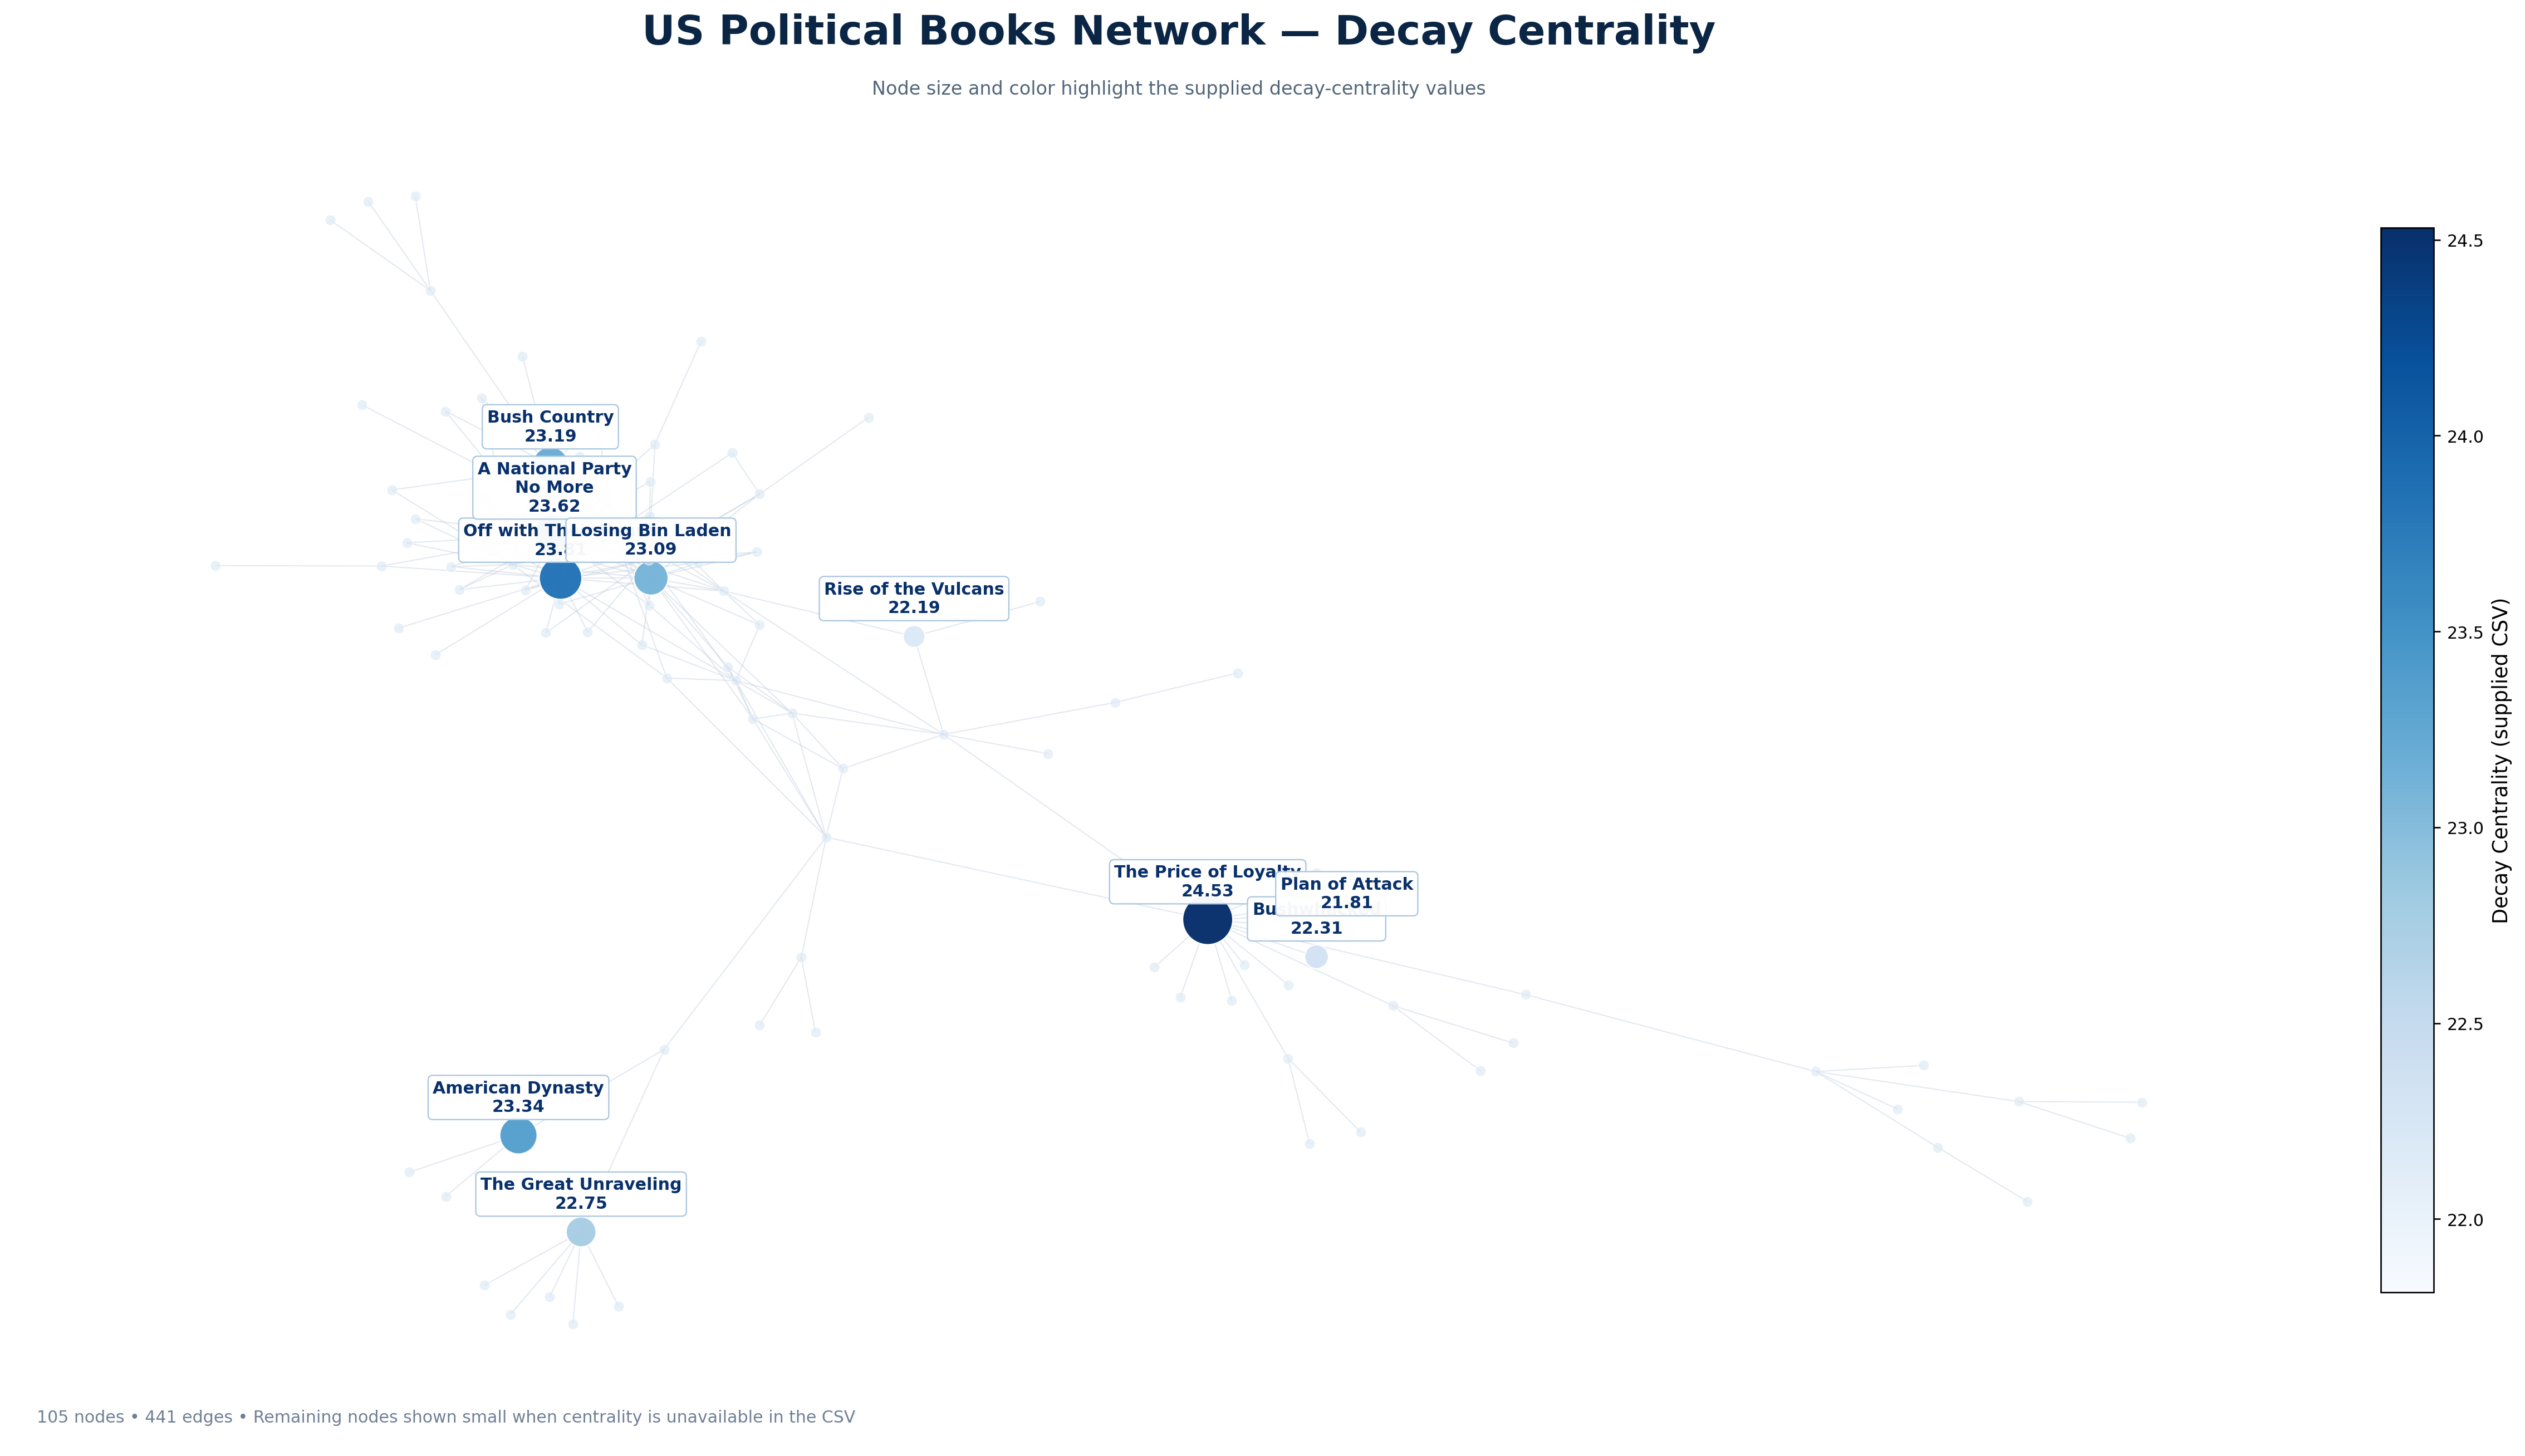

Completed visualization for polbooks

Generating graph: reachability
Nodes: 456 | Edges: 71959
Loaded 10 ranked Decay Centrality values.
Graph saved as: reachability_decay_centrality_presentation.png


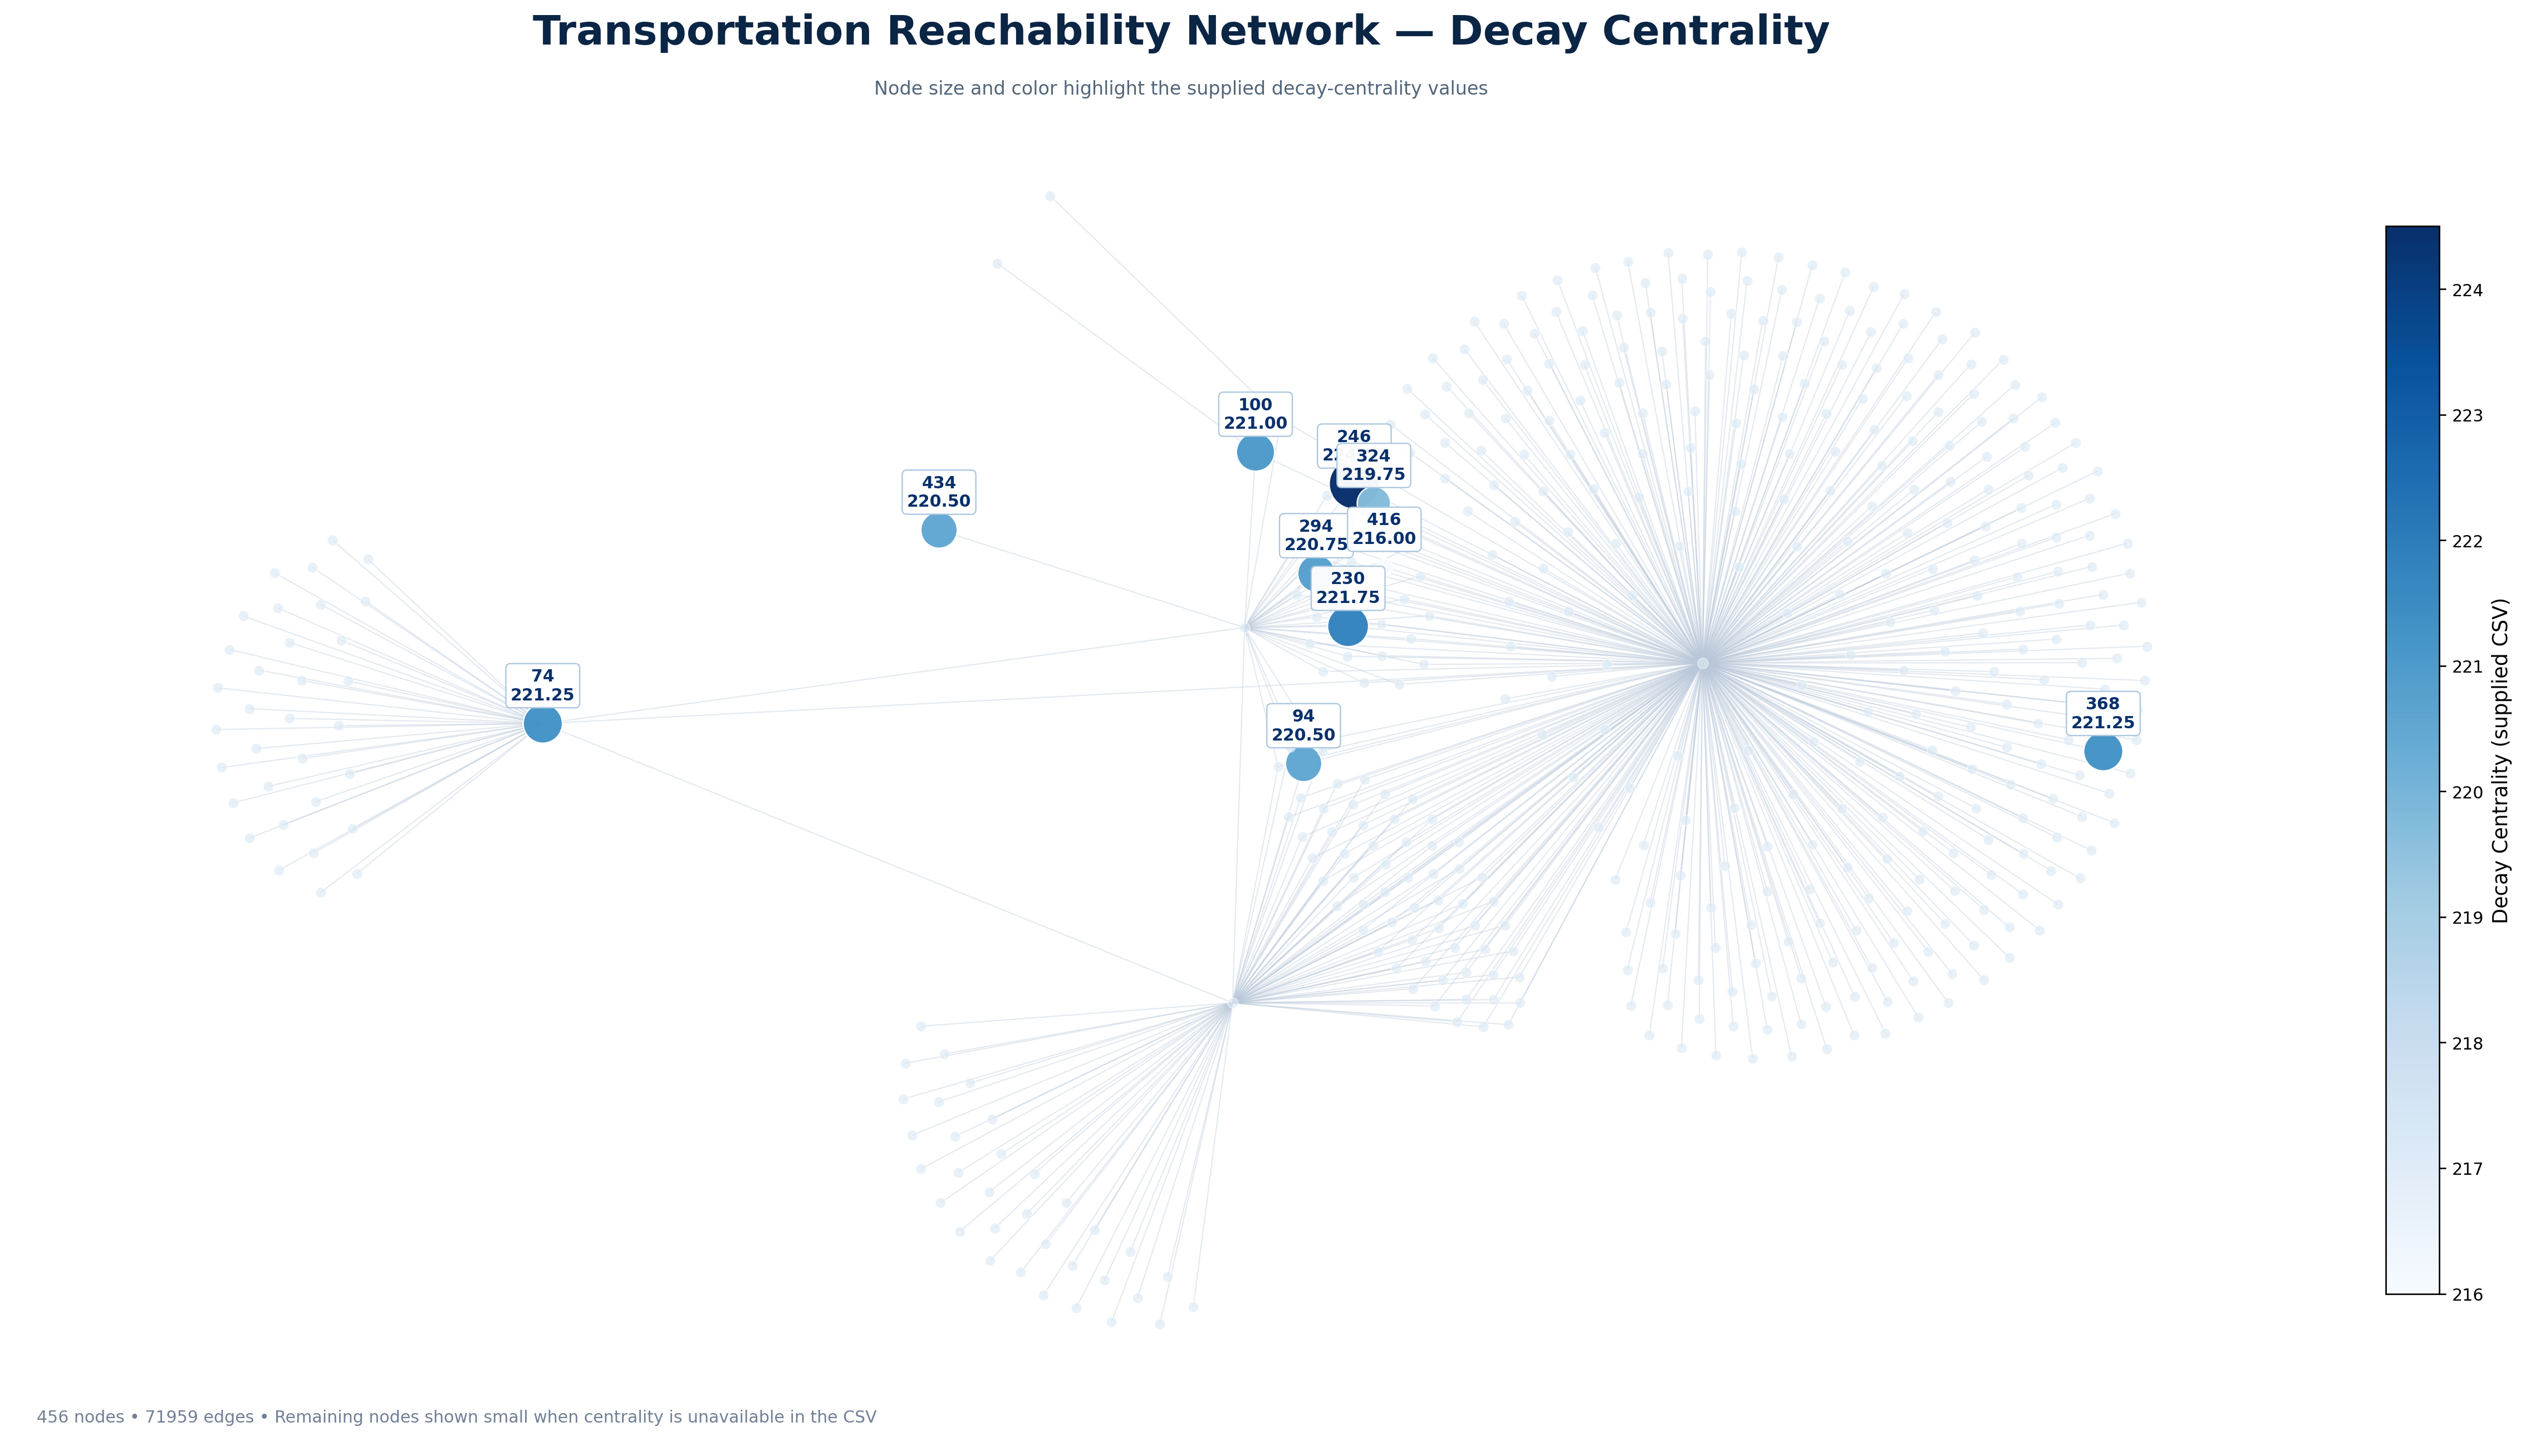

Completed visualization for reachability


In [7]:
for name, G in graphs.items():  # Iterate through all loaded graphs

    print(f"\nGenerating graph: {name}")  # Log current graph identifier
    print(
        f"Nodes: {G.number_of_nodes()} | "  # Print total node count in active graph
        f"Edges: {G.number_of_edges()}"  # Print total edge count in active graph
    )

    filename = f"{name}_results.csv"  # Construct standard path pointing to results CSV file

    # Load the supplied top-10 centrality values from file system if it exists
    if os.path.exists(filename):

        results_df = pd.read_csv(filename)  # Read results data into DataFrame

        centralities = dict(  # Zip IDs and centralities together into lookup dictionary
            zip(
                results_df["Node ID"],
                results_df["Custom Decay Centrality"]
            )
        )

        print(
            f"Loaded {len(centralities)} ranked "  # Log number of custom values successfully loaded
            f"Decay Centrality values."
        )

    else:  # If no CSV results exist yet, fall back on calculating values directly

        # Fallback: calculate values for all graph nodes using the main formula
        centralities = decay_centrality(
            G,
            delta=delta_value
        )

        print("Calculated centrality for all nodes.")  # Output verification message

    # Generate presentation-ready visualization and show layout on screen
    fig, ax = visualize_decay_graph(
        G=G,
        name=name,
        centralities=centralities,
        delta=delta_value,
        top_n_labels=10,
        figsize=(19, 11),
        save=True
    )

    plt.show()  # Explicitly trigger matplotlib display rendering

    print(f"Completed visualization for {name}")  # Log end of iteration block

### 5. Multi-Metric Correlation Analysis

Finally, we compute and compile the correlations (Pearson, Spearman, and Kendall's Tau) between our custom Decay Centrality and standard metrics to evaluate similarity and export the final report.

In [8]:
# Use the existing decay parameter
delta = delta_value  # Assign global delta parameter to working delta variable

all_correlation_results = []  # Initialize empty list to hold correlation record metrics
all_centrality_scores = {}  # Initialize empty dictionary to hold node scoring DataFrames

for name, G in graphs.items():  # Loop through loaded networks to perform correlation calculations

    print(f"\nProcessing dataset: {name}")  # Print dataset identifier message
    print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")  # Log size metrics

    # 1. Calculate existing Decay Centrality
    decay = decay_centrality(G, delta=delta)  # Generate Decay Centrality mapping dict

    # 2. Calculate other centrality measures using NetworkX library API functions
    centralities = {
        "Decay": decay,  # Insert custom Decay Centrality mapping dict
        "Degree": nx.degree_centrality(G),  # Compute standard node Degree Centrality
        "Closeness": nx.closeness_centrality(G),  # Compute standard node Closeness Centrality
        "Betweenness": nx.betweenness_centrality(G),  # Compute node Betweenness Centrality
        "PageRank": nx.pagerank(G)  # Compute PageRank scores
    }

    # Eigenvector Centrality
    try:
        # Compute Eigenvector Centrality with increased iterations to ensure convergence
        centralities["Eigenvector"] = nx.eigenvector_centrality(
            G, max_iter=5000, tol=1e-08
        )
    except nx.PowerIterationFailedConvergence:  # Handle cases where eigenvector solver fails convergence limits
        print(f"Warning: Eigenvector did not converge for {name}")  # Print warning
        centralities["Eigenvector"] = {  # Map nodes to NaN placeholder values
            node: np.nan for node in G.nodes()
        }

    # 3. Create centrality score table
    scores_df = pd.DataFrame(centralities)  # Build a combined pandas DataFrame indexing all calculated centralities

    all_centrality_scores[name] = scores_df  # Save combined dataframe to memory directory mapped by key

    # 4. Calculate correlations with Decay Centrality
    comparison_measures = [
        "Degree",
        "Closeness",
        "Betweenness",
        "Eigenvector",
        "PageRank"
    ]

    for measure in comparison_measures:  # Loop through standard comparative indicators

        valid = scores_df[["Decay", measure]].dropna()  # Isolate columns and drop rows with empty NaN values

        x = valid["Decay"]  # Isolate Decay Centrality vector
        y = valid[measure]  # Isolate current comparative measure vector

        # Handle constant-valued vectors to avoid statistical division-by-zero errors
        if len(valid) < 2 or x.nunique() < 2 or y.nunique() < 2:
            pearson = np.nan  # Set correlation result to NaN
            spearman = np.nan  # Set correlation result to NaN
            kendall = np.nan  # Set correlation result to NaN
        else:
            # Calculate Pearson, Spearman, and Kendall tau statistics using SciPy module
            pearson = pearsonr(x, y).statistic
            spearman = spearmanr(x, y).statistic
            kendall = kendalltau(x, y).statistic

        all_correlation_results.append({  # Record comparative dataset correlation results
            "Dataset": name,
            "Measure": measure,
            "Pearson": pearson,
            "Spearman": spearman,
            "Kendall": kendall
        })

    print(f"Completed: {name}")  # Log step end confirmation

# 5. Combine results from all datasets into a single tracking DataFrame
correlation_results_df = pd.DataFrame(all_correlation_results)

# 6. Display separate correlation tables
for name in graphs.keys():  # Loop through datasets to print structured stats tables

    print(f"\n{'='*60}")  # Print partition bar
    print(f"CORRELATION RESULTS: {name}")  # Print active dataset name
    print(f"{'='*60}")  # Print partition bar

    # Filter full table to extract statistics for the current active graph dataset
    dataset_result = correlation_results_df[
        correlation_results_df["Dataset"] == name
    ]

    print("\nTable 7: Pearson Correlation")  # Print table header
    display(
        dataset_result[["Measure", "Pearson"]]
        .set_index("Measure").T.round(4)
    )

    print("\nTable 8: Spearman Rank Correlation")  # Print table header
    display(
        dataset_result[["Measure", "Spearman"]]
        .set_index("Measure").T.round(4)
    )

    print("\nTable 9: Kendall's Tau")  # Print table header
    display(
        dataset_result[["Measure", "Kendall"]]
        .set_index("Measure").T.round(4)
    )

# 7. Export all results into one Excel workbook
with pd.ExcelWriter(
    "All_Datasets_Correlation_Analysis.xlsx",
    engine="openpyxl"
) as writer:

    # Save the master correlation results table into sheet
    correlation_results_df.to_excel(
        writer,
        sheet_name="All Correlations",
        index=False
    )

    for name, scores_df in all_centrality_scores.items():  # Write individual worksheets per network

        safe_name = name[:25].replace("/", "_")  # Sanitize name to make sure it is a valid Excel tab name

        scores_df.to_excel(
            writer,
            sheet_name=f"{safe_name}_Scores"
        )

        # Slice specific correlation records for current graph
        dataset_result = correlation_results_df[
            correlation_results_df["Dataset"] == name
        ]

        # Write subset correlation records to sheet
        dataset_result.to_excel(
            writer,
            sheet_name=f"{safe_name}_Correlation",
            index=False
        )

# 8. Save a CSV containing all correlation results as a simple format backup
correlation_results_df.to_csv(
    "All_Datasets_Correlation_Analysis.csv",
    index=False
)

# Print final reports summary outlining completed analysis
print("\nAll datasets processed successfully.")
print("Excel file: All_Datasets_Correlation_Analysis.xlsx")
print("CSV file: All_Datasets_Correlation_Analysis.csv")


Processing dataset: soc-karate
Nodes: 34, Edges: 78
Completed: soc-karate

Processing dataset: dolphins
Nodes: 62, Edges: 159
Completed: dolphins

Processing dataset: polbooks
Nodes: 105, Edges: 441
Completed: polbooks

Processing dataset: reachability
Nodes: 456, Edges: 71959
Completed: reachability

CORRELATION RESULTS: soc-karate

Table 7: Pearson Correlation


Measure,Degree,Closeness,Betweenness,Eigenvector,PageRank
Pearson,0.8587,0.9813,0.7831,0.9538,0.8283



Table 8: Spearman Rank Correlation


Measure,Degree,Closeness,Betweenness,Eigenvector,PageRank
Spearman,0.8617,0.9559,0.8397,0.925,0.7071



Table 9: Kendall's Tau


...


Table 8: Spearman Rank Correlation


Measure,Degree,Closeness,Betweenness,Eigenvector,PageRank
Spearman,0.9987,0.9942,0.9272,0.991,0.993



Table 9: Kendall's Tau


Measure,Degree,Closeness,Betweenness,Eigenvector,PageRank
Kendall,0.9767,0.9528,0.7866,0.9265,0.9448



All datasets processed successfully.
Excel file: All_Datasets_Correlation_Analysis.xlsx
CSV file: All_Datasets_Correlation_Analysis.csv
